# Jour 2 - Segmentation RFM de Lumina & Co

**Question métier :** qui sont nos clients et quels segments doivent recevoir une communication spécifique ?

Ce notebook reconstruit les indicateurs RFM depuis les transactions nettoyées, attribue des scores documentés, crée sept segments caractérisés et priorisés, puis teste un enrichissement zero-party.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = Path("Lumina & Co - CRM")
CUSTOMERS_PATH = DATA_DIR / "customers.csv"
TRANSACTIONS_PATH = DATA_DIR / "transactions.csv"

assert CUSTOMERS_PATH.exists() and TRANSACTIONS_PATH.exists()
print(f"pandas {pd.__version__} | données : {DATA_DIR.resolve()}")

pandas 2.3.3 | données : /Users/dorian/EDA/Lumina & Co - CRM


## 1. Construire les features RFM

### Règles de calcul

- **Snapshot date :** date maximale du dataset, fixée une fois pour toutes.
- **Récence :** jours depuis la dernière facture de vente positive.
- **Fréquence :** nombre de factures de vente positives distinctes.
- **Montant :** somme nette des lignes commerciales, retours compris.
- Les transactions anonymes, doublons exacts, prix négatifs et écritures non commerciales sont exclus de la segmentation.
- Les retours ne créent pas de commande supplémentaire, mais diminuent le montant net.

In [2]:
customer_dtypes = {
    "customer_id": "string",
    "country": "category",
    "n_orders": "Int64",
    "declared_preference": "category",
    "age_bracket": "category",
    "life_stage": "category",
    "urban_density": "category",
}
transaction_dtypes = {
    "invoice_id": "string",
    "customer_id": "string",
    "product_code": "string",
    "product_name": "category",
    "category": "category",
    "quantity": "int32",
    "unit_price": "float32",
    "country": "category",
}

customers = pd.read_csv(
    CUSTOMERS_PATH,
    dtype=customer_dtypes,
    parse_dates=["first_purchase", "last_purchase"],
).drop_duplicates()
transactions = pd.read_csv(
    TRANSACTIONS_PATH,
    dtype=transaction_dtypes,
    parse_dates=["invoice_date"],
).drop_duplicates()

NON_PRODUCT_CODES = {
    "POST", "DOT", "M", "D", "S", "C2", "BANK CHARGES", "ADJUST",
}
transactions["product_code"] = transactions["product_code"].str.upper()
transactions["line_total"] = transactions["quantity"] * transactions["unit_price"]
transactions["is_non_product"] = (
    transactions["product_code"].isin(NON_PRODUCT_CODES)
    | transactions["category"].eq("Frais")
)

commercial = transactions.loc[
    transactions["customer_id"].notna()
    & transactions["unit_price"].ge(0)
    & ~transactions["is_non_product"]
].copy()
positive_sales = commercial.loc[
    commercial["quantity"].gt(0) & commercial["unit_price"].gt(0)
].copy()

snapshot_date = transactions["invoice_date"].max().normalize()
print(f"Snapshot date : {snapshot_date.date()}")
print(f"Transactions commerciales identifiées : {len(commercial):,}")

Snapshot date : 2026-06-30
Transactions commerciales identifiées : 1,240,685


In [3]:
purchase_features = (
    positive_sales.groupby("customer_id", observed=True)
    .agg(
        first_purchase_calc=("invoice_date", "min"),
        last_purchase_calc=("invoice_date", "max"),
        frequency=("invoice_id", "nunique"),
        transaction_country=("country", "first"),
    )
)
net_monetary = (
    commercial.groupby("customer_id", observed=True)["line_total"]
    .sum()
    .rename("monetary")
)

# La segmentation part des transactions; le CRM enrichit ensuite le profil.
rfm = (
    purchase_features
    .join(net_monetary, how="left")
    .join(customers.set_index("customer_id"), how="left")
)
rfm["country"] = (
    rfm["country"].astype("string")
    .fillna(rfm["transaction_country"].astype("string"))
)
rfm["recency"] = (snapshot_date - rfm["last_purchase_calc"]).dt.days
rfm["tenure"] = (snapshot_date - rfm["first_purchase_calc"]).dt.days
rfm["avg_order_value"] = rfm["monetary"] / rfm["frequency"]

assert rfm.index.is_unique
assert rfm[["recency", "frequency", "monetary"]].notna().all().all()
assert rfm["recency"].ge(0).all()
assert rfm["frequency"].ge(1).all()

has_crm_reference = rfm["n_orders"].notna()
comparison = pd.DataFrame(
    {
        "recency_match_pct": [
            (rfm.loc[has_crm_reference, "recency"] == rfm.loc[has_crm_reference, "recency_days"]).mean() * 100
        ],
        "frequency_match_pct": [
            (rfm.loc[has_crm_reference, "frequency"] == rfm.loc[has_crm_reference, "n_orders"]).mean() * 100
        ],
        "monetary_close_pct": [
            np.isclose(
                rfm.loc[has_crm_reference, "monetary"],
                rfm.loc[has_crm_reference, "total_spent"],
                atol=0.02,
            ).mean() * 100
        ],
        "clients_segmentables": [len(rfm)],
        "sans_profil_crm": [(~has_crm_reference).sum()],
    }
).round(2)

display(rfm[["recency", "frequency", "monetary", "tenure", "avg_order_value"]].describe().T)
display(comparison)

,count,mean,std,min,25%,50%,75%,max
recency,49184.0,312.065997,295.389929,0.000000,72.000000,207.000000,489.000000,1635.000000
frequency,49184.0,4.375630,5.744057,1.000000,1.000000,3.000000,6.000000,373.000000
monetary,49184.0,794.961761,4077.492895,-888.089993,98.447502,237.080002,557.970001,409490.909978
tenure,49184.0,539.150903,299.080808,0.000000,315.000000,560.000000,731.000000,1635.000000
avg_order_value,49184.0,151.534825,304.182898,-754.110004,52.120000,76.616667,110.890835,9876.535294


,recency_match_pct,frequency_match_pct,monetary_close_pct,clients_segmentables,sans_profil_crm
0,11.93,78.18,6.9,49184,0


### Contrôle de cohérence avec `customers.csv`

Les agrégats reconstruits ne concordent que partiellement avec les colonnes pré-calculées du CRM. Ce constat persiste lorsque les retours et écritures non commerciales sont réintégrés : certains profils déclarent notamment une date de dernier achat absente du fichier de transactions, et les montants CRM sont souvent très supérieurs aux sommes recalculées.

Pour respecter la consigne du TP et garantir une méthode reproductible, les scores utilisent exclusivement les transactions disponibles. Les colonnes CRM servent au profilage et à la détection de cet écart de qualité, pas au calcul des scores. Une utilisation opérationnelle nécessiterait une réconciliation avec l'équipe responsable des données.

## 2. Attribuer les scores R, F et M

Les quintiles observés sont utilisés comme seuils. Pour la fréquence, `qcut` ne peut pas créer cinq groupes valides car 28,8 % des clients ont exactement une commande : le minimum et le premier quintile sont identiques. Afin de ne pas départager artificiellement des ex æquo, les paliers sont donc fixés aux bornes observées : 1, 2, 3-4, 5-7 et 8 commandes ou plus.

In [4]:
quantile_levels = [0, 0.2, 0.4, 0.6, 0.8, 1]
rfm_thresholds = pd.DataFrame(
    {
        "recency": rfm["recency"].quantile(quantile_levels),
        "frequency": rfm["frequency"].quantile(quantile_levels),
        "monetary": rfm["monetary"].quantile(quantile_levels),
    }
)
display(rfm_thresholds.round(2))

rfm["R"] = pd.qcut(rfm["recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F"] = pd.cut(
    rfm["frequency"],
    bins=[-np.inf, 1, 2, 4, 7, np.inf],
    labels=[1, 2, 3, 4, 5],
).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["rfm_score"] = (
    rfm["R"].astype(str) + rfm["F"].astype(str) + rfm["M"].astype(str)
)

score_distribution = pd.concat(
    {
        "R": rfm["R"].value_counts(normalize=True).sort_index(),
        "F": rfm["F"].value_counts(normalize=True).sort_index(),
        "M": rfm["M"].value_counts(normalize=True).sort_index(),
    },
    axis=1,
).mul(100)

assert rfm[["R", "F", "M"]].isin(range(1, 6)).all().all()
display(score_distribution.round(1).rename_axis("score"))

,recency,frequency,monetary
0.0,0.0,1.0,-888.09
0.2,56.0,1.0,77.63
0.4,136.0,2.0,171.36
0.6,308.0,4.0,328.97
0.8,561.0,7.0,683.35
1.0,1635.0,373.0,409490.91


,R,F,M
score,,,
1,20.0,29.7,20.0
2,20.0,17.4,20.0
3,19.9,20.9,20.0
4,20.0,15.0,20.0
5,20.2,16.9,20.0


## 3. Construire sept segments actionnables

Les quatre profils extrêmes du cours sont conservés. Le vaste groupe intermédiaire est divisé en trois profils selon sa récence, sa fréquence et sa valeur : **Fidèles**, **Potentiels fidèles** et **Occasionnels**. L'ordre des règles évite les chevauchements.

In [5]:
segment_conditions = [
    rfm["R"].ge(4) & rfm["F"].ge(4) & rfm["M"].ge(4),
    rfm["R"].le(2) & rfm["F"].ge(3) & rfm["M"].ge(3),
    rfm["R"].le(2) & rfm["F"].le(2) & rfm["M"].le(2),
    rfm["R"].ge(4) & rfm["F"].le(2) & rfm["M"].le(2),
    rfm["F"].ge(4) & rfm["M"].ge(3),
    rfm["R"].ge(3) & rfm["F"].between(2, 3),
]
segment_names = [
    "Champions",
    "À risque",
    "Perdus",
    "Nouveaux prometteurs",
    "Fidèles",
    "Potentiels fidèles",
]
rfm["segment"] = np.select(segment_conditions, segment_names, default="Occasionnels")

segment_order = [
    "À risque",
    "Champions",
    "Potentiels fidèles",
    "Nouveaux prometteurs",
    "Fidèles",
    "Occasionnels",
    "Perdus",
]
rfm["segment"] = pd.Categorical(rfm["segment"], categories=segment_order, ordered=True)

assert rfm["segment"].notna().all()
assert rfm["segment"].nunique() == 7
print(rfm["segment"].value_counts(sort=False).to_string())

segment
À risque                 4704
Champions                9334
Potentiels fidèles       9420
Nouveaux prometteurs     4068
Fidèles                  4338
Occasionnels             6574
Perdus                  10746


## 4. Profiler et prioriser les segments

La priorité combine valeur immédiate, risque de perte et potentiel de croissance. Elle doit se traduire par des traitements réellement différents, pas uniquement par un numéro.

In [6]:
segment_profile = (
    rfm.groupby("segment", observed=True)
    .agg(
        clients=("recency", "size"),
        recency_median=("recency", "median"),
        frequency_median=("frequency", "median"),
        monetary_median=("monetary", "median"),
        monetary_total=("monetary", "sum"),
        avg_order_value=("avg_order_value", "mean"),
        tenure_median=("tenure", "median"),
    )
    .reindex(segment_order)
)
segment_profile["client_share_pct"] = segment_profile["clients"].div(len(rfm)).mul(100)
segment_profile["revenue_share_pct"] = segment_profile["monetary_total"].div(rfm["monetary"].sum()).mul(100)

country_mix = pd.crosstab(rfm["segment"], rfm["country"], normalize="index")
segment_profile["top_country"] = country_mix.idxmax(axis=1)
segment_profile["top_country_share_pct"] = country_mix.max(axis=1).mul(100)

segment_strategy = pd.DataFrame(
    {
        "priority": [1, 2, 3, 4, 5, 6, 7],
        "criterion": [
            "Risque de perte d'une valeur historique élevée",
            "Valeur immédiate et coût d'une défection",
            "Potentiel de croissance vers une relation régulière",
            "Potentiel de deuxième achat à court terme",
            "Valeur récurrente à entretenir efficacement",
            "Potentiel incertain : limiter le coût de contact",
            "Faible valeur et faible probabilité de retour",
        ],
        "action": [
            "Relance personnalisée en 2 temps avec rappel des produits achetés, puis avantage limité",
            "Programme VIP, accès anticipé et recommandations sans remise systématique",
            "Séquence de nurturing et vente croisée fondée sur la dernière catégorie achetée",
            "Onboarding post-achat et rappel d'usage pour déclencher une deuxième commande",
            "Programme de fidélité et réapprovisionnement automatisé",
            "Campagnes email automatisées à faible coût et tests de contenu",
            "Exclusion des médias payants; campagne de permission occasionnelle seulement",
        ],
        "success_metric": [
            "Taux de réactivation à 30 jours",
            "Taux de réachat et valeur à 90 jours",
            "Passage à 3 commandes sous 90 jours",
            "Taux de deuxième commande à 30 jours",
            "Fréquence et panier sur 90 jours",
            "Revenu incrémental par email envoyé",
            "Coût évité et taux de réactivation organique",
        ],
    },
    index=segment_order,
)
segment_map = segment_profile.join(segment_strategy)

display(
    segment_map[
        [
            "priority", "clients", "client_share_pct", "revenue_share_pct",
            "recency_median", "frequency_median", "monetary_median",
            "avg_order_value", "tenure_median", "top_country",
        ]
    ].round(1)
)

,priority,clients,client_share_pct,revenue_share_pct,recency_median,frequency_median,monetary_median,avg_order_value,tenure_median,top_country
segment,,,,,,,,,,
À risque,1,4704,9.6,8.1,454.0,4.0,355.1,137.4,822.0,France
Champions,2,9334,19.0,61.7,53.0,9.0,826.2,204.5,583.0,France
Potentiels fidèles,3,9420,19.2,12.5,126.0,3.0,246.7,178.8,331.0,France
Nouveaux prometteurs,4,4068,8.3,0.8,62.0,1.0,70.5,58.2,72.0,France
Fidèles,5,4338,8.8,8.8,181.0,7.0,497.9,102.6,640.0,France
Occasionnels,6,6574,13.4,6.1,409.0,1.0,199.3,285.2,519.0,France
Perdus,7,10746,21.8,2.0,647.0,1.0,68.6,61.1,698.0,France


In [7]:
# Réponses aux trois profils extrêmes demandés dans le TP
exact_111 = rfm["rfm_score"].eq("111")
champions = rfm["segment"].eq("Champions")
at_risk = rfm["segment"].eq("À risque")

key_answers = pd.DataFrame(
    {
        "clients": [champions.sum(), at_risk.sum(), exact_111.sum()],
        "part_base_pct": [champions.mean() * 100, at_risk.mean() * 100, exact_111.mean() * 100],
        "part_ca_pct": [
            rfm.loc[champions, "monetary"].sum() / rfm["monetary"].sum() * 100,
            rfm.loc[at_risk, "monetary"].sum() / rfm["monetary"].sum() * 100,
            rfm.loc[exact_111, "monetary"].sum() / rfm["monetary"].sum() * 100,
        ],
    },
    index=["Champions (proches de 555)", "À risque", "Perdus exacts (111)"],
)
display(key_answers.round(1))

for segment, row in segment_map.sort_values("priority").iterrows():
    print(
        f"{int(row['priority'])}. Pour le segment {segment}, caractérisé par "
        f"R={row['recency_median']:.0f} jours, F={row['frequency_median']:.0f} commandes "
        f"et M médian={row['monetary_median']:.0f} €, priorisé parce que "
        f"{row['criterion'].lower()}, on propose : {row['action']}."
    )

,clients,part_base_pct,part_ca_pct
Champions (proches de 555),9334,19.0,61.7
À risque,4704,9.6,8.1
Perdus exacts (111),3609,7.3,0.4


1. Pour le segment À risque, caractérisé par R=454 jours, F=4 commandes et M médian=355 €, priorisé parce que risque de perte d'une valeur historique élevée, on propose : Relance personnalisée en 2 temps avec rappel des produits achetés, puis avantage limité.
2. Pour le segment Champions, caractérisé par R=53 jours, F=9 commandes et M médian=826 €, priorisé parce que valeur immédiate et coût d'une défection, on propose : Programme VIP, accès anticipé et recommandations sans remise systématique.
3. Pour le segment Potentiels fidèles, caractérisé par R=126 jours, F=3 commandes et M médian=247 €, priorisé parce que potentiel de croissance vers une relation régulière, on propose : Séquence de nurturing et vente croisée fondée sur la dernière catégorie achetée.
4. Pour le segment Nouveaux prometteurs, caractérisé par R=62 jours, F=1 commandes et M médian=71 €, priorisé parce que potentiel de deuxième achat à court terme, on propose : Onboarding post-achat et rappel d'usage pour déclencher u

## 5. Visualiser les scores et la matrice RFM

La matrice croise récence et fréquence; sa couleur représente la valeur moyenne. Le nuage récence × montant utilise une échelle logarithmique pour conserver la lisibilité malgré les clients à très forte valeur.

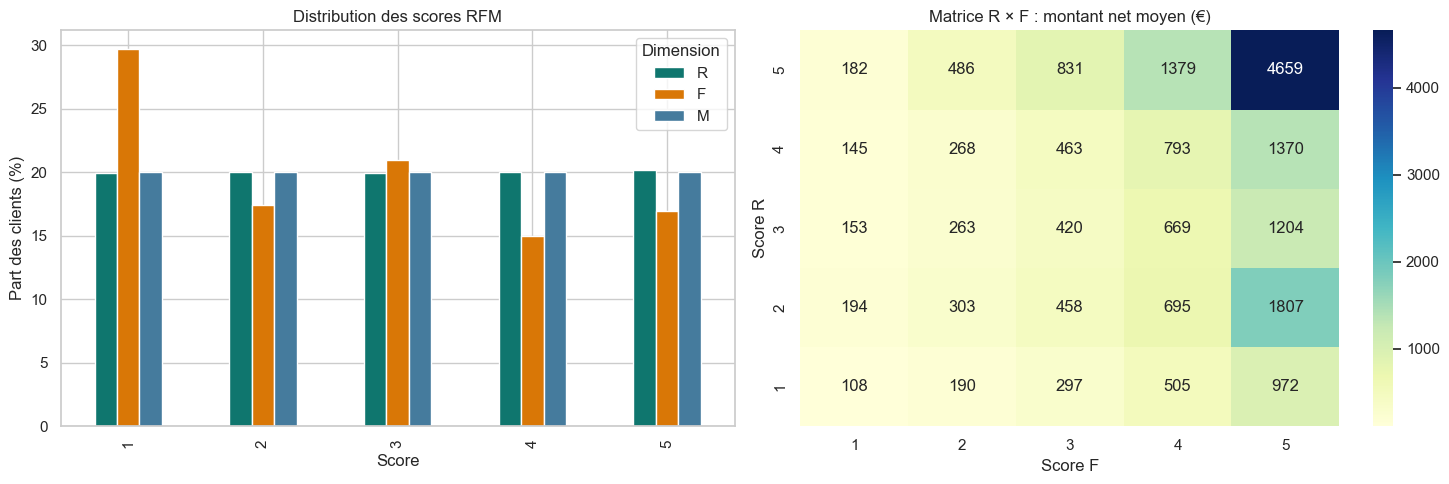

In [8]:
segment_palette = {
    "À risque": "#B91C1C",
    "Champions": "#0F766E",
    "Potentiels fidèles": "#2563EB",
    "Nouveaux prometteurs": "#7C3AED",
    "Fidèles": "#15803D",
    "Occasionnels": "#D97706",
    "Perdus": "#6B7280",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
score_distribution.plot(kind="bar", ax=axes[0], color=["#0F766E", "#D97706", "#457B9D"])
axes[0].set(title="Distribution des scores RFM", xlabel="Score", ylabel="Part des clients (%)")
axes[0].legend(title="Dimension")

rf_matrix = pd.pivot_table(
    rfm,
    index="R",
    columns="F",
    values="monetary",
    aggfunc="mean",
    observed=True,
)
sns.heatmap(rf_matrix.sort_index(ascending=False), annot=True, fmt=".0f", cmap="YlGnBu", ax=axes[1])
axes[1].set(title="Matrice R × F : montant net moyen (€)", xlabel="Score F", ylabel="Score R")

fig.tight_layout()
plt.show()

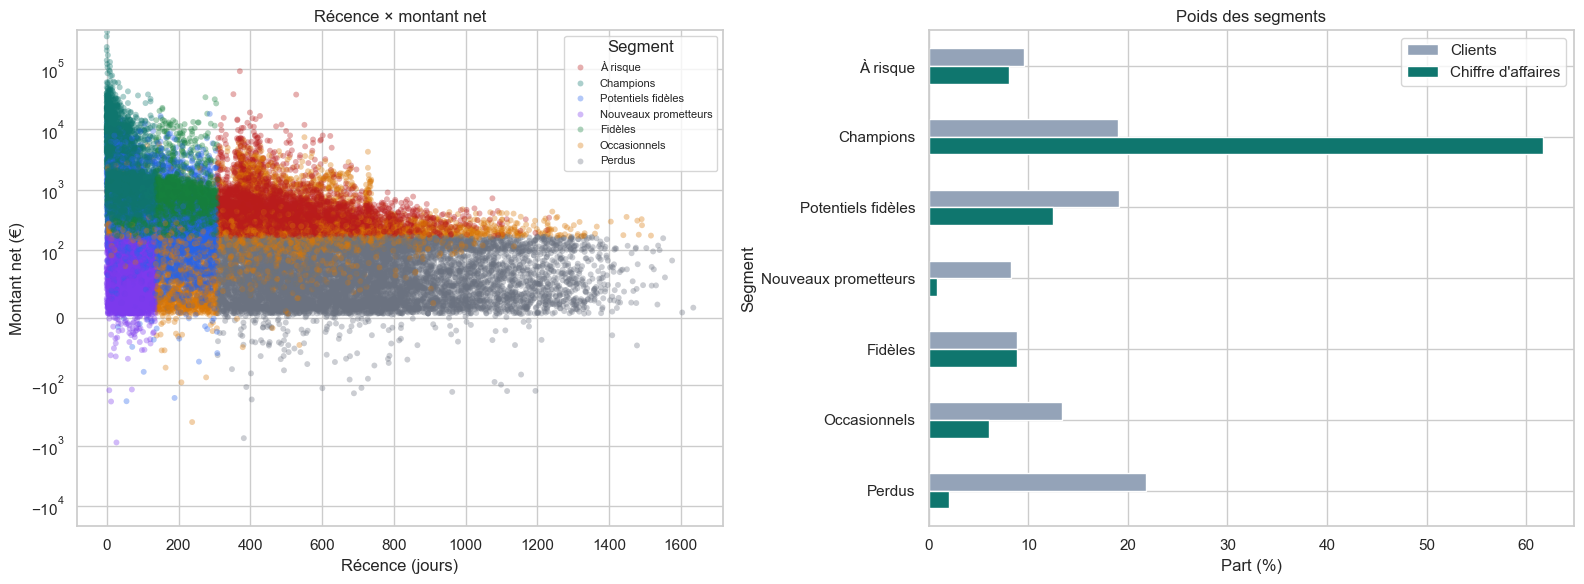

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=rfm,
    x="recency",
    y="monetary",
    hue="segment",
    hue_order=segment_order,
    palette=segment_palette,
    alpha=0.35,
    s=18,
    linewidth=0,
    ax=axes[0],
)
axes[0].set_yscale("symlog", linthresh=100)
axes[0].set(title="Récence × montant net", xlabel="Récence (jours)", ylabel="Montant net (€)")
axes[0].legend(title="Segment", fontsize=8)

shares = segment_map.sort_values("priority")[["client_share_pct", "revenue_share_pct"]]
shares.plot(kind="barh", ax=axes[1], color=["#94A3B8", "#0F766E"])
axes[1].invert_yaxis()
axes[1].set(title="Poids des segments", xlabel="Part (%)", ylabel="Segment")
axes[1].legend(["Clients", "Chiffre d'affaires"])

fig.tight_layout()
plt.show()

## 6. Enrichissement insight-driven avec la zero-party data

Le segment **À risque**, prioritaire pour sa valeur historique menacée, est croisé avec `declared_preference`. Les pourcentages de préférences portent uniquement sur les répondants; le taux de couverture est affiché séparément afin de ne pas confondre absence de réponse et absence de préférence.

,taux_remplissage_pct
Ensemble de la base,38.0
À risque,38.4


,Ensemble des répondants,Répondants À risque
declared_preference,,
Peau sensible,14.7,15.0
Anti-âge,14.5,14.6
Anti-imperfections,14.4,15.5
Recherche vegan,14.3,15.0
Peau mixte,14.2,13.7
Peau sèche,14.0,14.3
Sans parfum,14.0,12.0


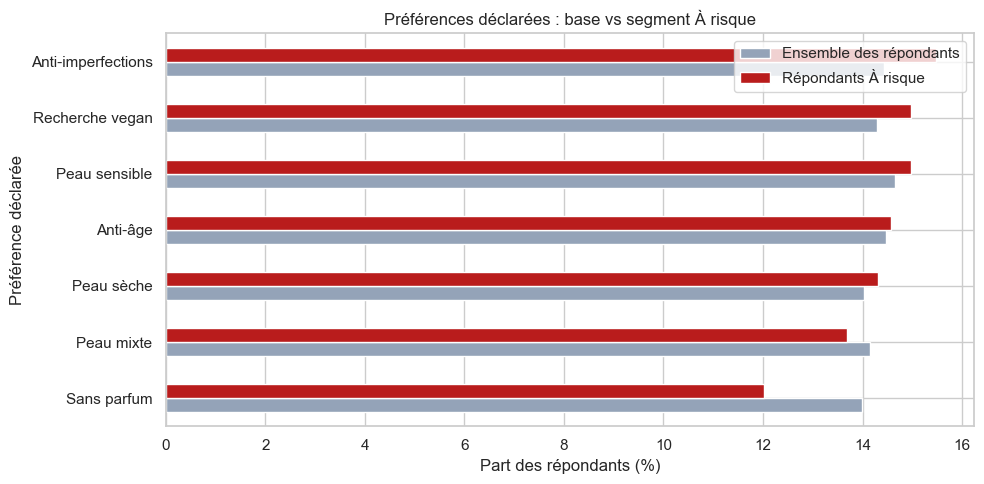

Insight : la préférence la plus fréquente parmi les répondants À risque est « Anti-imperfections ». Le message de relance peut mettre en avant cette préoccupation et les produits déjà achetés. Le canal ne peut pas être individualisé avec ces deux fichiers : un email ne doit être utilisé que si la base légale et le droit d'opposition sont vérifiés.


In [10]:
target_segment = "À risque"
target_mask = rfm["segment"].eq(target_segment)
preference_coverage = pd.Series(
    {
        "Ensemble de la base": rfm["declared_preference"].notna().mean() * 100,
        target_segment: rfm.loc[target_mask, "declared_preference"].notna().mean() * 100,
    },
    name="taux_remplissage_pct",
)

preference_comparison = pd.concat(
    {
        "Ensemble des répondants": rfm["declared_preference"].value_counts(normalize=True),
        f"Répondants {target_segment}": rfm.loc[target_mask, "declared_preference"].value_counts(normalize=True),
    },
    axis=1,
).mul(100).fillna(0)

display(preference_coverage.round(1).to_frame())
display(preference_comparison.round(1))

preference_comparison.sort_values(f"Répondants {target_segment}").plot(
    kind="barh",
    figsize=(10, 5),
    color=["#94A3B8", segment_palette[target_segment]],
)
plt.title("Préférences déclarées : base vs segment À risque")
plt.xlabel("Part des répondants (%)")
plt.ylabel("Préférence déclarée")
plt.tight_layout()
plt.show()

leading_preference = preference_comparison[f"Répondants {target_segment}"].idxmax()
print(
    f"Insight : la préférence la plus fréquente parmi les répondants À risque est "
    f"« {leading_preference} ». Le message de relance peut mettre en avant cette préoccupation "
    "et les produits déjà achetés. Le canal ne peut pas être individualisé avec ces deux fichiers : "
    "un email ne doit être utilisé que si la base légale et le droit d'opposition sont vérifiés."
)

## 7. Plan d'activation secondaire : préférence et âge

Le RFM détermine **l'objectif et le budget**. La préférence déclarée détermine **l'angle produit**. La tranche d'âge adapte **le ton et le format**, sans déduire un métier, un genre ou un âge exact absent des données.

Les deux champs sont utilisés indépendamment : 64,6 % des profils possèdent au moins l'un des deux, mais seulement 16,3 % possèdent les deux. Une valeur de repli conserve les autres clients dans leur segment RFM.

In [ ]:
segment_actions = {
    "À risque": {
        "objectif": "Réactiver une valeur historique menacée",
        "action": "Relance en deux temps : rappel personnalisé, puis avantage limité",
        "cadence": "J0 puis J+7; arrêt après conversion ou opposition",
        "kpi": "Taux de réactivation à 30 jours",
    },
    "Champions": {
        "objectif": "Protéger la valeur et renforcer l'attachement",
        "action": "Programme VIP, accès anticipé et recommandation personnalisée",
        "cadence": "Communication relationnelle mensuelle, hors messages transactionnels",
        "kpi": "Taux de réachat et valeur à 90 jours",
    },
    "Potentiels fidèles": {
        "objectif": "Installer une habitude d'achat",
        "action": "Nurturing et vente croisée vers une routine complémentaire",
        "cadence": "Séquence de 3 messages sur 30 jours",
        "kpi": "Passage à 3 commandes sous 90 jours",
    },
    "Nouveaux prometteurs": {
        "objectif": "Déclencher la deuxième commande",
        "action": "Onboarding, conseils d'usage et rappel de réapprovisionnement",
        "cadence": "J+3, J+14 et rappel selon le cycle produit",
        "kpi": "Taux de deuxième commande à 30 jours",
    },
    "Fidèles": {
        "objectif": "Maintenir la fréquence et le panier",
        "action": "Fidélité, réapprovisionnement et découverte de nouveautés",
        "cadence": "Message adapté au cycle moyen de réachat",
        "kpi": "Fréquence et panier à 90 jours",
    },
    "Occasionnels": {
        "objectif": "Tester le potentiel sans surinvestir",
        "action": "Campagnes automatisées à faible coût avec test de contenu",
        "cadence": "Un test mensuel maximum",
        "kpi": "Revenu incrémental par message",
    },
    "Perdus": {
        "objectif": "Limiter le coût et vérifier l'intérêt résiduel",
        "action": "Exclusion des médias payants et campagne de permission ponctuelle",
        "cadence": "Une campagne de reconquête, puis mise en sommeil",
        "kpi": "Coût évité et réactivation organique",
    },
}

preference_angles = {
    "Anti-âge": "Routine fermeté et prévention, avec preuve d'usage et conseils de régularité",
    "Anti-imperfections": "Routine simple anti-imperfections, non agressive et progressive",
    "Peau sensible": "Tolérance, douceur, composition rassurante et routine courte",
    "Peau mixte": "Équilibre des zones et routine modulable",
    "Peau sèche": "Hydratation, confort et nutrition durable",
    "Recherche vegan": "Sélection vegan, transparence des ingrédients et engagements",
    "Sans parfum": "Produits sans parfum, simplicité des formules et tolérance",
    "Non renseignée": "Recommandation fondée sur le dernier produit ou la catégorie achetée",
}

age_tones = {
    "18-24 ans": "Format court, visuel et pédagogique; offre d'entrée accessible",
    "25-34 ans": "Routine efficace, gain de temps et bénéfices concrets",
    "35-44 ans": "Conseil expert, routine ciblée et résultats attendus",
    "45-54 ans": "Expertise, confort d'usage et accompagnement dans la durée",
    "55 ans et plus": "Message clair, lisible, rassurant et service client visible",
    "Non renseignée": "Ton neutre et inclusif, sans supposition démographique",
}

rfm["preference_activation"] = rfm["declared_preference"].astype("string").fillna("Non renseignée")
rfm["age_activation"] = rfm["age_bracket"].astype("string").fillna("Non renseignée")
segment_as_text = rfm["segment"].astype("string")
rfm["objectif_activation"] = segment_as_text.map({key: value["objectif"] for key, value in segment_actions.items()})
rfm["action_activation"] = segment_as_text.map({key: value["action"] for key, value in segment_actions.items()})
rfm["cadence_activation"] = segment_as_text.map({key: value["cadence"] for key, value in segment_actions.items()})
rfm["kpi_activation"] = segment_as_text.map({key: value["kpi"] for key, value in segment_actions.items()})
rfm["angle_offre"] = rfm["preference_activation"].map(preference_angles)
rfm["ton_message"] = rfm["age_activation"].map(age_tones)
rfm["persona_activation"] = (
    segment_as_text + " | " + rfm["preference_activation"] + " | " + rfm["age_activation"]
)

activation_columns = [
    "objectif_activation", "action_activation", "cadence_activation",
    "kpi_activation", "angle_offre", "ton_message", "persona_activation",
]
assert rfm[activation_columns].notna().all().all()

activation_coverage = pd.Series(
    {
        "Préférence renseignée": rfm["declared_preference"].notna().mean() * 100,
        "Âge renseigné": rfm["age_bracket"].notna().mean() * 100,
        "Au moins une information secondaire": rfm[["declared_preference", "age_bracket"]].notna().any(axis=1).mean() * 100,
        "Préférence et âge renseignés": rfm[["declared_preference", "age_bracket"]].notna().all(axis=1).mean() * 100,
    },
    name="couverture_pct",
)

actionable_groups = (
    rfm.groupby(["segment", "preference_activation", "age_activation"], observed=True)
    .agg(clients=("recency", "size"), montant_median=("monetary", "median"))
    .query("clients >= 30")
    .sort_values("clients", ascending=False)
)

display(activation_coverage.round(1).to_frame())
display(actionable_groups.head(20).round(1))
display(rfm[activation_columns].head())

## 8. Conclusion et limites

- La segmentation remplace l'envoi uniforme par sept traitements différenciés et mesurables.
- Les segments **À risque** et **Champions** reçoivent l'essentiel de l'attention humaine; les segments moins rentables passent par des dispositifs automatisés ou sont exclus des canaux coûteux.
- Les seuils de fréquence conservent les ex æquo : les groupes ne contiennent donc pas exactement 20 % des clients, ce qui est préférable à une séparation arbitraire.
- Le montant est net des retours valides, tandis que la fréquence et la récence reposent sur les achats positifs.
- Le RFM décrit le comportement passé et ne démontre pas la causalité d'une action marketing.
- Les données zero-party sont incomplètes; leur croisement produit une piste de personnalisation, pas une conclusion représentative de tout le segment.
- Pour une base d'environ 50 clients, les quintiles seraient trop instables : des seuils métier fixes fondés sur le cycle de réachat et des montants interprétables seraient préférables.
- Avant activation, la base légale, le consentement applicable, le droit d'opposition et les durées de conservation doivent être vérifiés.